##start


In [15]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [16]:
import pandas as pd
from pathlib import Path

In [17]:
from pathlib import Path
import requests
import shutil

##transform

In [18]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(227, 227)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor(), # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

# The data


#ImageFolder

In [19]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root="./project_img", # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None,
                                  ) # transforms to perform on labels (if necessary)


In [20]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
test_data = datasets.ImageFolder(root="./test", # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None,
                                  ) # transforms to perform on labels (if necessary)

# New Section

In [21]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

one image from train data

datils on the image

## an image from train data

In [22]:
from torch.utils.data import DataLoader

##dataLoader

In [23]:
# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=32, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)


In [24]:
# Turn datasets into iterables (batches)
test_dataloader = DataLoader(test_data, # dataset to turn into iterable
    batch_size=32, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

#img- after dataloader able-after dataloader

In [25]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    # print(torch.eq(y_true, y_pred).sum(), len(y_pred))
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100

    return acc

In [35]:

class convolutionModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=96,
                      kernel_size=11,
                      stride=4,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3,
                         stride=2),
            nn.Conv2d(in_channels=96,
                      out_channels=256,
                      kernel_size=5,
                      stride=1,
                      padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3,
                         stride=2)
             )
        #print(hidden_units)
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=256,
                      out_channels=384,
                      stride=1,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
             nn.Conv2d(in_channels=384,
                      out_channels=384,
                      stride=1,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
             nn.Conv2d(in_channels=384,
                      out_channels=256,
                      stride=1,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
          nn.MaxPool2d(kernel_size=3, 
                      stride=2)
        )
        
        self.clssiftion = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= 256 * 6 *6,
                      out_features=output_shape)
        )


    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
#         print(x.shape)
        x = self.block_2(x)
#         print(x.shape)
        x = self.clssiftion(x)
        return x
torch.manual_seed(42)
model_experemntal = convolutionModel(input_shape=3,
                                     hidden_units=10,
                                     output_shape=8)


In [33]:




# משתנים
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_experemntal.parameters(),
                            lr=0.1)
device = "cuda" if torch.cuda.is_available() else "cpu"


# פונקציית אימון
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)


        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))  # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()
        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss} | Train accuracy: {train_acc}%")


# פונקציית טסט
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()  # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1)  # Go from logits -> pred labels
                                    )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")





In [36]:
from timeit import default_timer as timer

train_time_start_model_0 = timer()

epochs = 10

for epoch in range(epochs):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader= train_dataloader,
               model=model_experemntal,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device
               )
    test_step(data_loader= test_dataloader,
               model=model_experemntal,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               device=device
               )

Epoch: 0
---------
Train loss: 2.0806326866149902 | Train accuracy: 20.39665725047081%
Test loss: 2.07848 | Test accuracy: 13.54%

Epoch: 1
---------
Train loss: 2.080626964569092 | Train accuracy: 20.37664783427495%
Test loss: 2.07848 | Test accuracy: 13.54%

Epoch: 2
---------
Train loss: 2.080645799636841 | Train accuracy: 20.39665725047081%
Test loss: 2.07854 | Test accuracy: 13.22%

Epoch: 3
---------
Train loss: 2.080644130706787 | Train accuracy: 20.366643126177024%
Test loss: 2.07853 | Test accuracy: 13.30%

Epoch: 4
---------
Train loss: 2.080636739730835 | Train accuracy: 20.386652542372882%
Test loss: 2.07842 | Test accuracy: 13.46%

Epoch: 5
---------
Train loss: 2.0806398391723633 | Train accuracy: 20.37664783427495%
Test loss: 2.07842 | Test accuracy: 13.54%

Epoch: 6
---------
Train loss: 2.080644130706787 | Train accuracy: 20.386652542372882%
Test loss: 2.07843 | Test accuracy: 13.46%

Epoch: 7
---------
Train loss: 2.0806217193603516 | Train accuracy: 20.40666195856873

In [17]:
from pathlib import Path
#Create models directory (if it doesn't already exist), see: 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

#Create model save path
MODEL_NAME = "13_secsess_big_.pth.tar"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_experemntal.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models\13_secsess_big_.pth.tar


In [22]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
from pathlib import Path
loaded_model_0 =convolutionModel(input_shape=3,
                                     hidden_units=10,
                                     output_shape=8)

# Load in the saved state_dict()
loaded_model_0.load_state_dict(torch.load(f="./models/13_secsess_big_.pth.tar"))

# Send model to GPU
loaded_model_0 = loaded_model_0.to(device)

In [23]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
      loss, acc = 0, 0
      model.eval()
      with torch.inference_mode():
          for X, y in data_loader:
              # Send data to the target device
              X, y = X.to(device), y.to(device)
              y_pred = model(X)
              loss += loss_fn(y_pred, y)
              acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

          # Scale loss and acc
          loss /= len(data_loader)
          acc /= len(data_loader)
      return {"model_name": model.__class__.__name__, # only works when model was created with a class
              "model_loss": loss.item(),
              "model_acc": acc}

In [24]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [25]:
class_names =train_data.classes
len(class_names)

8

In [26]:
import random
random.seed(2)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([3, 64, 64])
Test sample label: 0 (Library)


In [27]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=loaded_model_0, 
                             data=test_samples)



In [28]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
print(pred_probs)
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([[8.5943e-01, 5.7850e-03, 9.6379e-04, 9.4877e-04, 9.5630e-02, 3.0066e-02,
         5.4988e-03, 1.6764e-03],
        [9.7647e-01, 2.1578e-03, 4.1033e-04, 4.3098e-03, 7.9740e-03, 6.3736e-03,
         2.1709e-03, 1.3457e-04],
        [4.6072e-01, 1.2578e-01, 4.9723e-02, 1.7707e-01, 2.5480e-03, 4.3186e-02,
         2.5212e-02, 1.1576e-01],
        [5.6423e-07, 7.0079e-06, 3.7967e-05, 9.1774e-03, 4.4610e-08, 6.4633e-06,
         4.1963e-08, 9.9077e-01],
        [6.7112e-05, 7.7670e-01, 1.0062e-06, 2.2263e-01, 7.3289e-06, 9.2831e-05,
         5.0082e-04, 6.7586e-07],
        [2.8344e-04, 1.3387e-03, 3.7214e-01, 5.3014e-01, 5.7750e-04, 1.1903e-03,
         6.4834e-04, 9.3689e-02],
        [1.0235e-03, 4.1602e-02, 1.6071e-01, 3.0585e-01, 4.3457e-05, 2.1392e-02,
         3.2684e-03, 4.6611e-01],
        [3.6348e-10, 2.8935e-07, 1.0000e+00, 1.2291e-07, 2.8797e-09, 7.1911e-08,
         4.6402e-07, 1.8541e-08],
        [5.9368e-05, 6.2865e-05, 9.9962e-01, 1.1886e-05, 2.8060e-06, 2.2376e-05,

tensor([0, 0, 0, 7, 1, 3, 7, 2, 2])

In [29]:
# Are our predictions in the same form as our test labels? 
test_labels, pred_classes

([0, 0, 0, 3, 1, 7, 6, 2, 2], tensor([0, 0, 0, 7, 1, 3, 7, 2, 2]))

In [30]:
import matplotlib.pyplot as plt

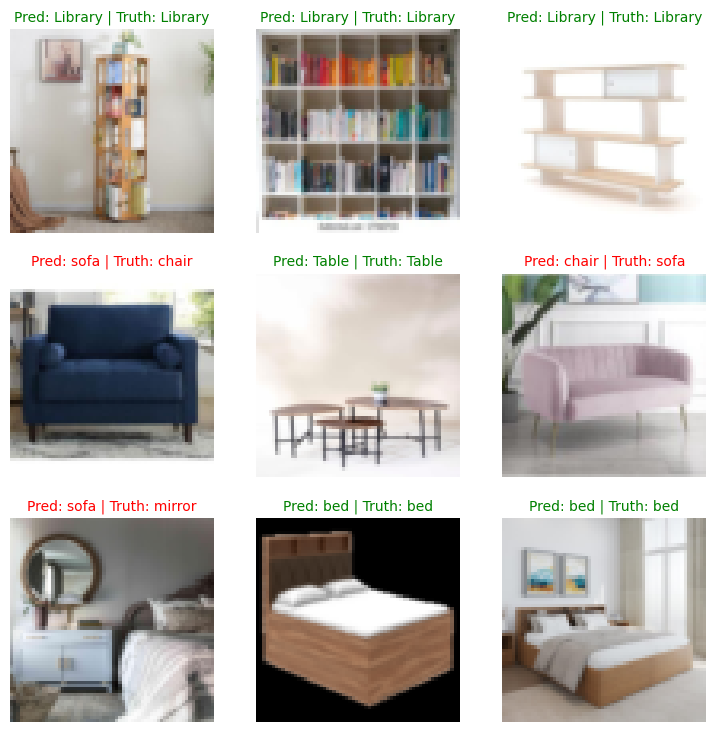

In [31]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)
  
  sample = sample.permute(1, 2, 0)
  # Plot the target image
  plt.imshow(sample)
    
    # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]
     # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);





In [32]:
torch.manual_seed(42)

loaded_model_0_results = eval_model(
    model=loaded_model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_0_results

{'model_name': 'convolutionModel',
 'model_loss': 0.6109517216682434,
 'model_acc': 78.42808380414313}

In [33]:
torch.manual_seed(42)

loaded_model_0_results = eval_model(
    model=loaded_model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_0_results

{'model_name': 'convolutionModel',
 'model_loss': 1.1863789558410645,
 'model_acc': 64.98397435897435}

In [34]:
import tensorflow as tf

In [35]:
import os,cv2,keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import shutil


In [36]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

torch.Size([3, 64, 64])
torch.Size([64, 64, 3])


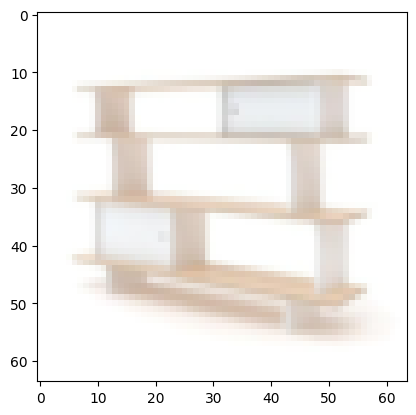

In [37]:
img = test_samples[2]
print(img.shape)
img= img.permute(1, 2, 0)
print(img.shape)
plt.imshow(img)   

In [38]:
class_names[2]

'bed'

In [39]:
stack=[]
print(test_samples[0].shape)

torch.Size([3, 64, 64])


In [40]:
annot = "./"
path= "./project_img/bed"

<class 'numpy.ndarray'>
tensor(2)
tensor(0.7013)
273 96 18 70
tensor(2)
tensor(1.)
362 281 150 99


c:\users\hp\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:33: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


tensor(2)
tensor(0.7777)
248 167 80 58
tensor(2)
tensor(0.9125)
410 453 50 38
tensor(2)
tensor(0.9949)
493 338 6 35
tensor(2)
tensor(0.9156)
212 288 107 32
tensor(2)
tensor(0.9707)
372 116 45 51
tensor(2)
tensor(0.9996)
476 101 7 162
tensor(2)
tensor(1.0000)
0 265 14 13
tensor(2)
tensor(0.9557)
20 206 27 49
tensor(2)
tensor(1.)
214 0 63 179
tensor(2)
tensor(0.8703)
414 319 58 23
tensor(2)
tensor(0.9353)
352 261 128 72
tensor(2)
tensor(1.)
273 155 11 25
tensor(2)
tensor(0.7540)
219 95 293 295
tensor(2)
tensor(1.)
330 111 150 73
tensor(2)
tensor(0.8034)
28 192 232 67
tensor(2)
tensor(1.)
186 0 91 196
tensor(2)
tensor(1.)
45 29 2 195
tensor(2)
tensor(1.0000)
326 106 148 77
tensor(2)
tensor(0.8561)
406 106 64 62
tensor(2)
tensor(1.0000)
0 265 14 16
tensor(2)
tensor(0.9999)
48 33 4 172
tensor(2)
tensor(0.9966)
450 228 27 6
tensor(2)
tensor(0.7005)
283 310 30 113
tensor(2)
tensor(0.9337)
294 341 15 52
tensor(2)
tensor(0.9997)
451 176 25 51
tensor(2)
tensor(0.8036)
350 348 14 45
28


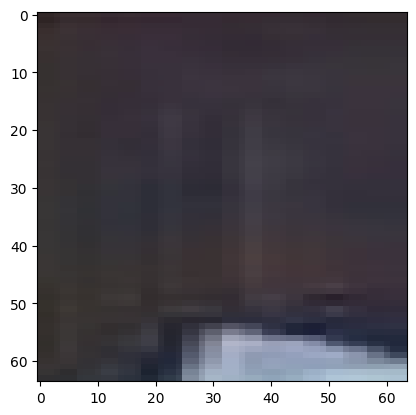

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

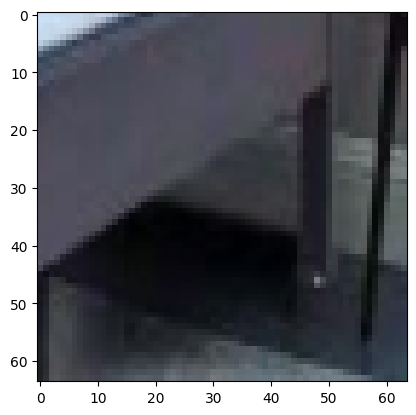

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

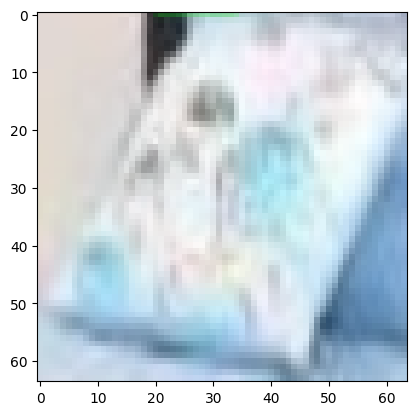

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

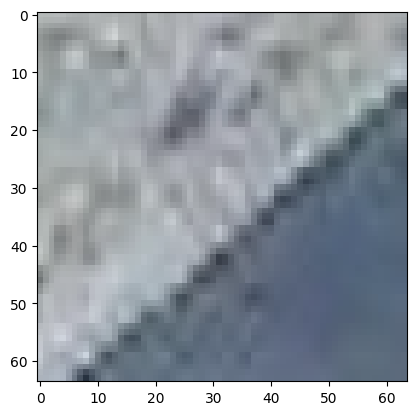

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

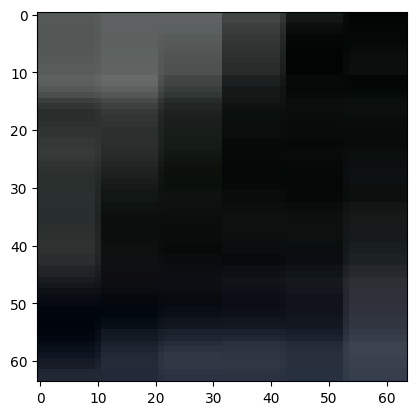

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

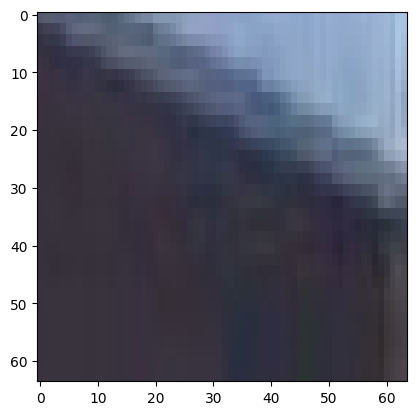

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

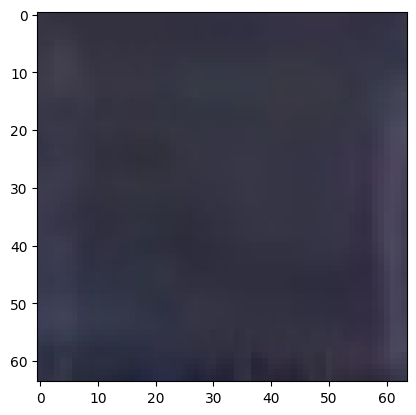

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

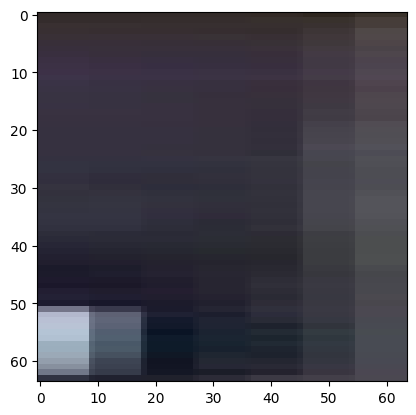

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

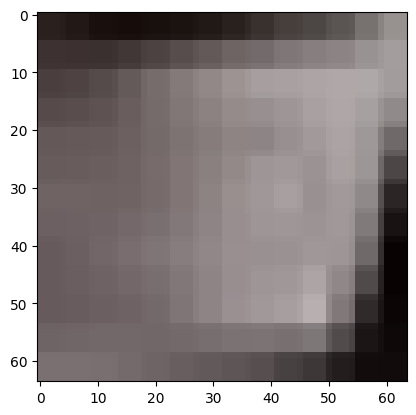

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

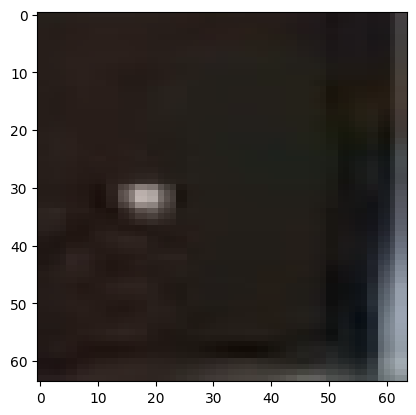

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

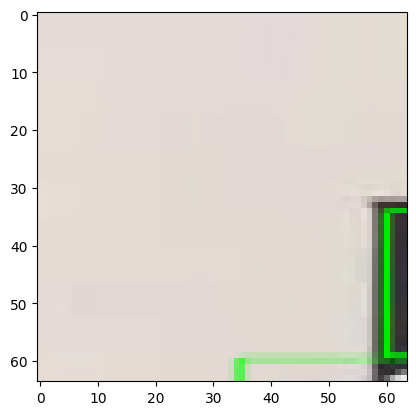

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

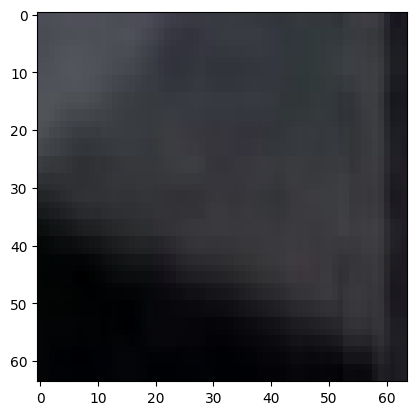

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

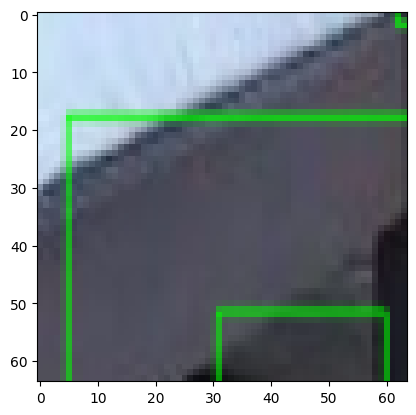

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

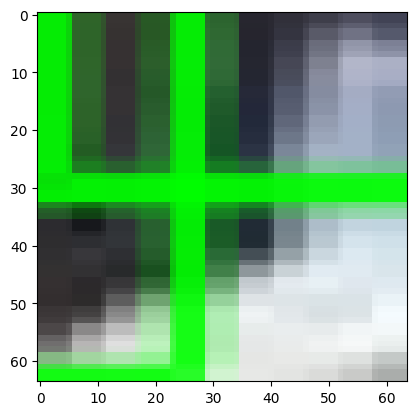

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

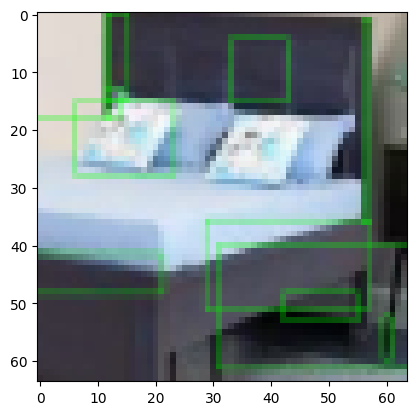

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

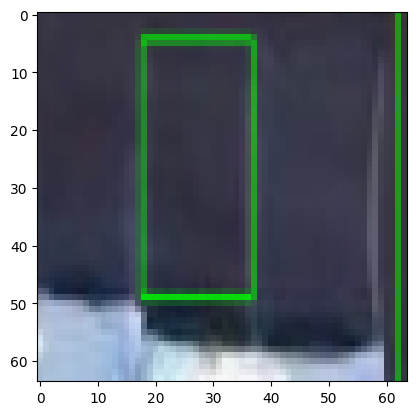

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

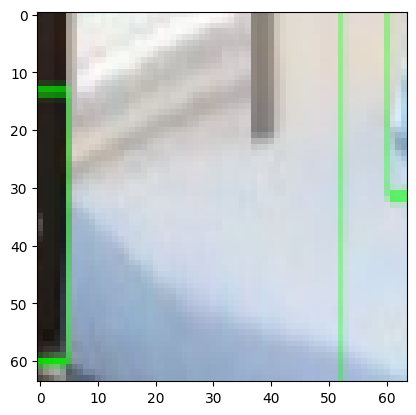

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

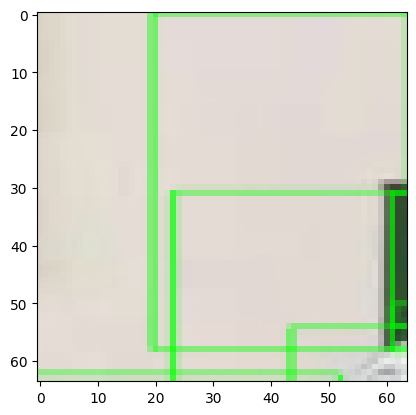

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

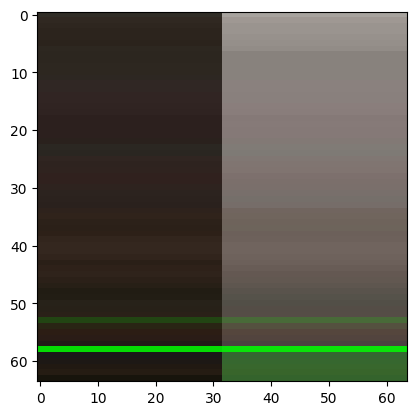

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

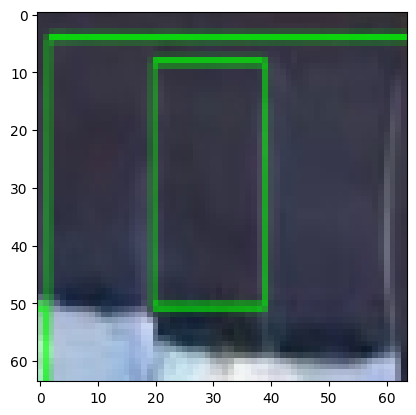

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

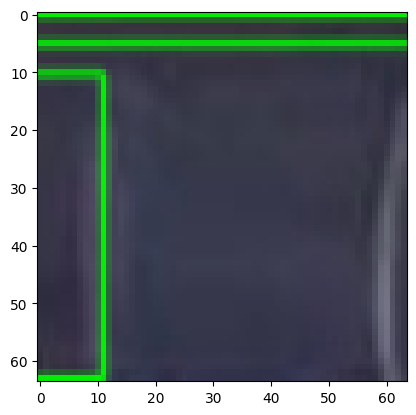

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

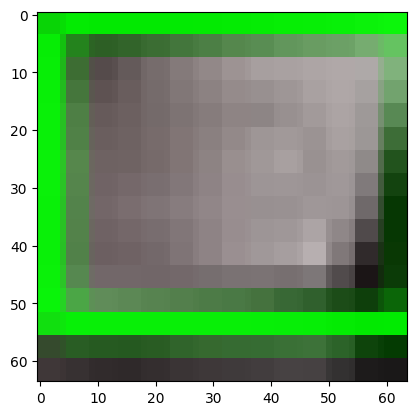

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

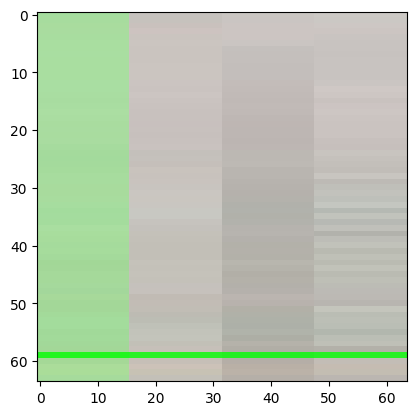

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

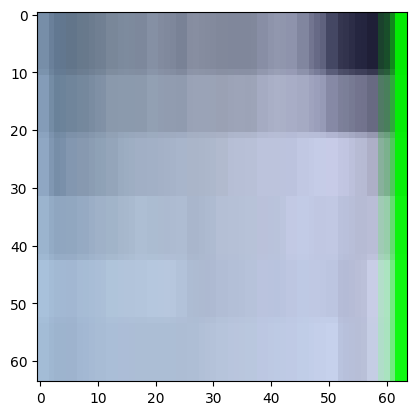

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

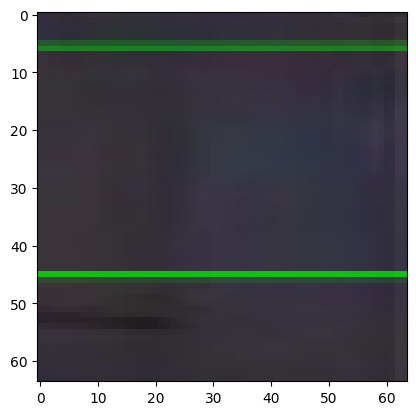

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

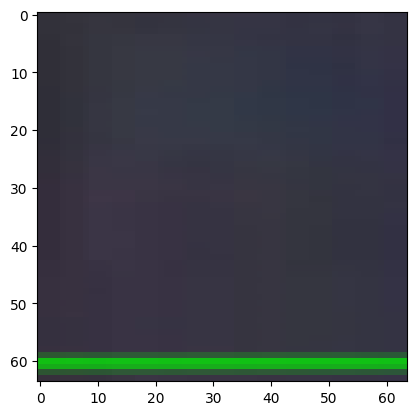

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

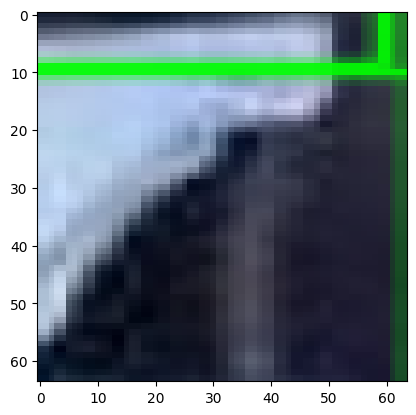

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

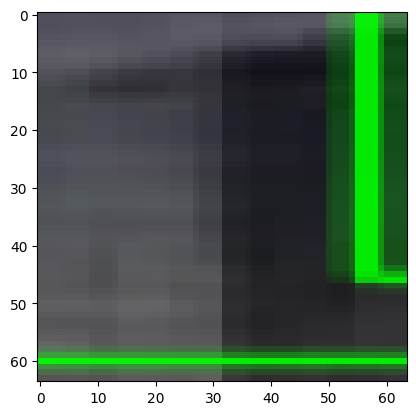

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

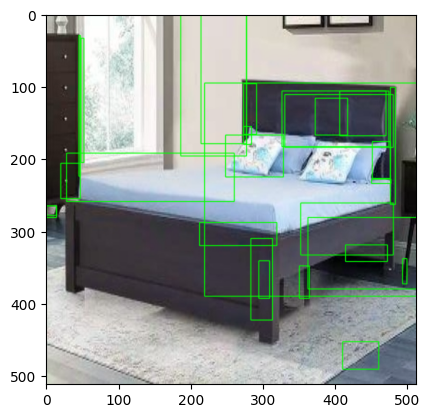

In [172]:
z=0
sum_true=0
max1= 0.0000

for e,i in enumerate(os.listdir(path)):
    z += 1
    img = cv2.imread(os.path.join(path,i))
#     print(img.shape)
    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    ssresults = ss.process()
    print(type(ssresults))
    imout = img.copy()
    for e,result in enumerate(ssresults):
        if e < 1000:
            x,y,w,h = result
            timage = imout[y:y+h,x:x+w]
            resized = cv2.resize(timage, (64,64), interpolation = cv2.INTER_AREA)
            img = np.expand_dims(resized, axis=0)
            img = torch.tensor(img)
            img1 = img.to(torch.float32)
#             print(img.shape)
            img1 = img1.permute(0, 3, 1, 2)
#             print(img.shape)
#             stack.append(img)
            out= make_predictions(model=loaded_model_0, 
                                 data=img1)
            
            pred_classes = out.argmax(dim=1)
            img = img.permute(0, 1, 2, 3)
#             print(img.shape)
            img = img.squeeze(dim=0)
            plt.figure()
#             f=float(torch.round(out[0][pred_classes[0]]))
#             print(f)
            if torch.eq(pred_classes[0], torch.Tensor([2])) and out[0][pred_classes[0]]>= torch.tensor(0.7) :
                cv2.rectangle(imout, (x, y), (x+w, y+h), (0, 255, 0), 1, cv2.LINE_AA)
#                 max1 = f
                print(pred_classes[0])
                print(out[0][pred_classes[0]])
                print(x,y,w,h)
                sum_true+=1
                plt.imshow(img)
                
    plt.figure()
    plt.imshow(imout)
    print(sum_true)
    break

In [ ]:
np.array([[264, 276], [215, 239], [253, 287], [252, 273], [251, 274], [257, 254]])

c:\users\hp\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


0


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

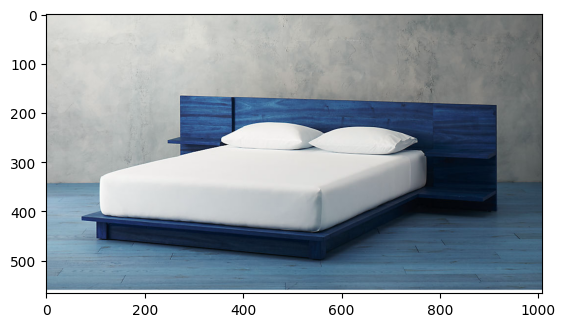

In [47]:
z=0
sum_true=0
max1= 0.0000

for e,i in enumerate(os.listdir(path)):
    z += 1
    img = cv2.imread(os.path.join(path,i))
#     print(img.shape)
    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    ssresults = ss.process()
    myresults =np.array([[450, 276], [400, 239], [420, 287], [350, 273], [400, 274], [405, 254]])
    imout = img.copy()
    for e,result in enumerate(myresults):
        if e < 6:
            w,h = result
            x,y=100,160
            for i in range(100, 800, 20):
                for i in range(160, 800, 20):    
                    timage = imout[y:y+h,x:x+w]
                    resized = cv2.resize(timage, (64,64), interpolation = cv2.INTER_AREA)
                    img = np.expand_dims(resized, axis=0)
                    img = torch.tensor(img)
                    img1 = img.to(torch.float32)
        #             print(img.shape)
                    img1 = img1.permute(0, 3, 1, 2)
        #             print(img.shape)
        #             stack.append(img)
                    out= make_predictions(model=loaded_model_0, 
                                         data=img1)

                    pred_classes = out.argmax(dim=1)
                    img = img.permute(0, 1, 2, 3)
        #             print(img.shape)
                    img = img.squeeze(dim=0)
                    plt.figure()
        #             f=float(torch.round(out[0][pred_classes[0]]))
        #             print(f)
                    if torch.eq(pred_classes[0], torch.Tensor([2])):
                        cv2.rectangle(imout, (x, y), (x+w, y+h), (0, 255, 0), 1, cv2.LINE_AA)
        #                 max1 = f
                        print(pred_classes[0])
                        print(out[0][pred_classes[0]])
                        print(x,y,w,h)
                        sum_true+=1
                        x+=1
                        plt.imshow(img)
                y+=1
    plt.figure()
    plt.imshow(imout)
    print(sum_true)
    break

In [ ]:
z=0
sum_true=0
minx=0
miny=0
maxXandWithd=0
maxyandHight=0
allxy= np.array([[]])
for e,i in enumerate(os.listdir(path)):
    z += 1
    img = cv2.imread(os.path.join(path,i))
#     print(img.shape)
    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    ssresults = ss.process()
    print(type(ssresults))
    imout = img.copy()
    for e,result in enumerate(ssresults):
        if e < 1000:
            x,y,w,h = result
            timage = imout[y:y+h,x:x+w]
            resized = cv2.resize(timage, (64,64), interpolation = cv2.INTER_AREA)
            img = np.expand_dims(resized, axis=0)
            img = torch.tensor(img)
            img1 = img.to(torch.float32)
#             print(img.shape)
            img1 = img1.permute(0, 3, 1, 2)
#             print(img.shape)
#             stack.append(img)
            out= make_predictions(model=loaded_model_0, 
                                 data=img1)
            
            pred_classes = out.argmax(dim=1)
            img = img.permute(0, 1, 2, 3)
#             print(img.shape)
            img = img.squeeze(dim=0)
            plt.figure()
#             f=float(torch.round(out[0][pred_classes[0]]))
#             print(f)
            if torch.eq(pred_classes[0], torch.Tensor([2])) and out[0][pred_classes[0]]>= torch.tensor(0.9)and x+w>=600 and y+h>500:
                cv2.rectangle(imout, (x, y), (x+w, y+h), (255, 255, 255), 1, cv2.LINE_AA)
                print(pred_classes[0])
                print(out[0][pred_classes[0]])
                print(x,y,w,h)
                sum_true+=1
                if minx>x:
                    minx=x
                if miny>y:
                    miny=y
                if maxXandWithd<(x+w):
                    maxXandWithd= x+w
                if maxyandHight<(y+h):
                    maxyandHight=y+h
    print(minx)  
    print(miny) 
    print(maxXandWithd)
    print(maxyandHight)
#     cv2.rectangle(imout, (minx, miny), (maxXandWithd, maxyandHight), (255, 0, 255), 1, cv2.LINE_AA)# The out line will be red           
    plt.figure()
    plt.imshow(imout)
    print(sum_true)

<class 'numpy.ndarray'>


c:\users\hp\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


tensor(2)
tensor(1.)
848 529 38 17
tensor(2)
tensor(1.)
72 172 936 331
tensor(2)
tensor(1.)
824 499 184 11
tensor(2)
tensor(1.)
875 527 133 18
tensor(2)
tensor(1.)
0 172 1008 388
tensor(2)
tensor(1.)
824 499 184 10
tensor(2)
tensor(1.)
840 527 168 23
tensor(2)
tensor(1.0000)
808 500 32 10
tensor(2)
tensor(1.)
584 527 288 5
tensor(2)
tensor(1.0000)
0 461 1008 99
tensor(2)
tensor(1.)
733 527 275 19
tensor(2)
tensor(1.)
561 507 255 5
tensor(2)
tensor(1.)
848 528 40 19
0
0
1008
560
13
<class 'numpy.ndarray'>
tensor(2)
tensor(1.)
0 149 1008 411
tensor(2)
tensor(1.)
887 538 121 10
tensor(2)
tensor(1.0000)
607 507 41 6
tensor(2)
tensor(1.)
885 538 123 11
tensor(2)
tensor(1.)
592 456 43 49
tensor(2)
tensor(1.)
632 335 104 176
tensor(2)
tensor(1.)
0 138 1008 422
tensor(2)
tensor(1.)
854 531 35 19
tensor(2)
tensor(1.)
866 486 50 18
tensor(2)
tensor(1.)
512 332 232 173
0
0
1008
560
23
<class 'numpy.ndarray'>
tensor(2)
tensor(1.)
121 343 595 225
tensor(2)
tensor(1.)
120 337 595 185
tensor(2)
tenso

tensor(2)
tensor(1.)
224 869 728 2
tensor(2)
tensor(1.)
788 650 300 37
tensor(2)
tensor(1.)
736 871 332 1
tensor(2)
tensor(1.)
1092 676 1 108
tensor(2)
tensor(1.)
46 674 1044 113
tensor(2)
tensor(1.)
1054 644 52 254
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
0
0
1450
1140
200
<class 'numpy.ndarray'>
tensor(2)
tensor(1.)
555 496 104 10
tensor(2)
tensor(1.)
931 503 77 14
0
0
1450
1140
202
<class 'numpy.ndarray'>
tensor(2)
tensor(1.)
532 352 476 207
